Original Shape: (6362620, 11)

Data types after encoding:
step                int64
type                int64
amount            float64
oldbalanceOrg     float64
newbalanceOrig    float64
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

First 5 rows:
   step  type    amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
0     1     3   9839.64       170136.0       160296.36             0.0   
1     1     3   1864.28        21249.0        19384.72             0.0   
2     1     4    181.00          181.0            0.00             0.0   
3     1     1    181.00          181.0            0.00         21182.0   
4     1     3  11668.14        41554.0        29885.86             0.0   

   newbalanceDest  isFraud  isFlaggedFraud  
0             0.0        0               0  
1             0.0        0               0  
2             0.0        1               0  
3             0.0        1               0  
4        

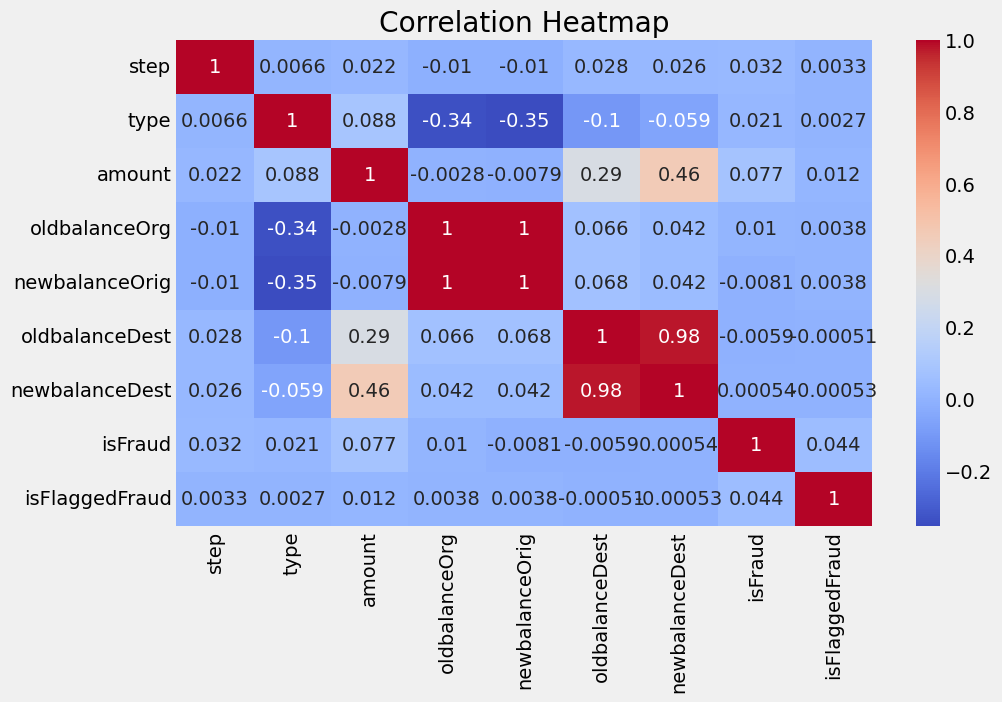

✅ Done!


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

plt.style.use('fivethirtyeight')

# Step 1: Read data
df = pd.read_csv('PS_20174392719_1491204439457_log.csv')
print("Original Shape:", df.shape)

# Step 2: Drop unnecessary columns
df = df.drop(['nameOrig', 'nameDest'], axis=1)

# Step 3: Encode 'type' column IMMEDIATELY
le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])

# Step 4: Verify all columns are now numeric
print("\nData types after encoding:")
print(df.dtypes)
print("\nFirst 5 rows:")
print(df.head())

# Step 5: NOW draw heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

print("✅ Done!")

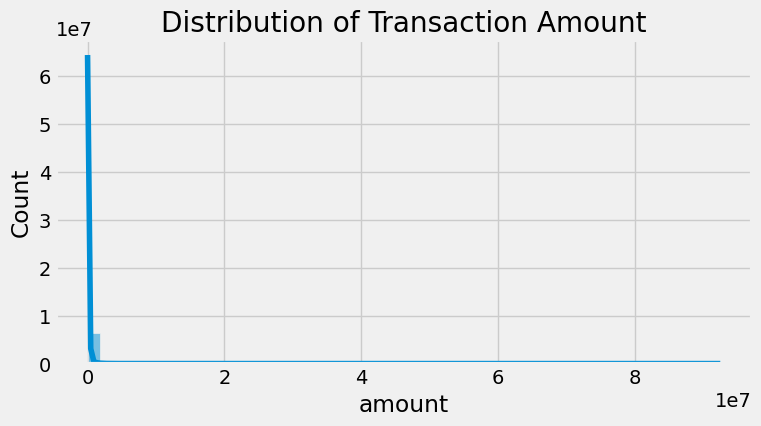

In [2]:
plt.figure(figsize=(8, 4))
sns.histplot(df['amount'], bins=50, kde=True)
plt.title("Distribution of Transaction Amount")
plt.show()

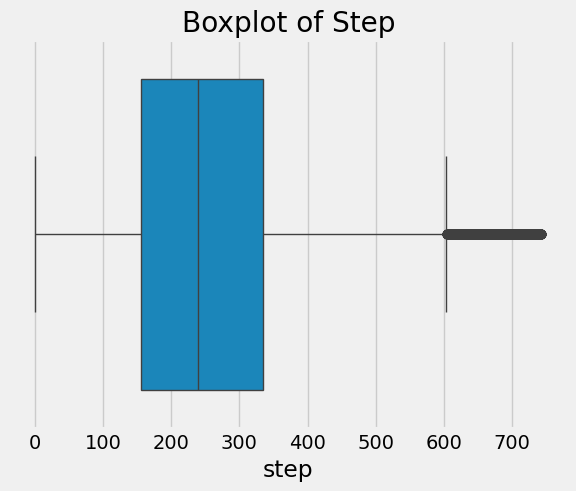

In [3]:
sns.boxplot(x=df['step'])
plt.title("Boxplot of Step")
plt.show()

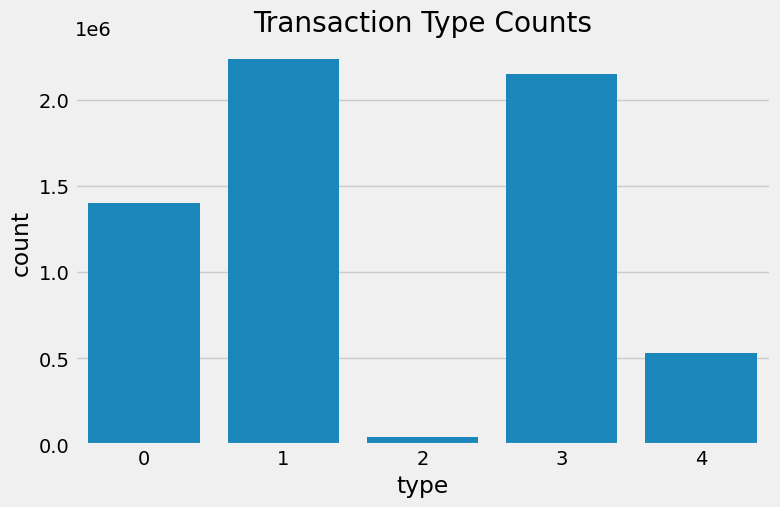

In [4]:
plt.figure(figsize=(8, 5))
sns.countplot(x='type', data=df)
plt.title("Transaction Type Counts")
plt.show()

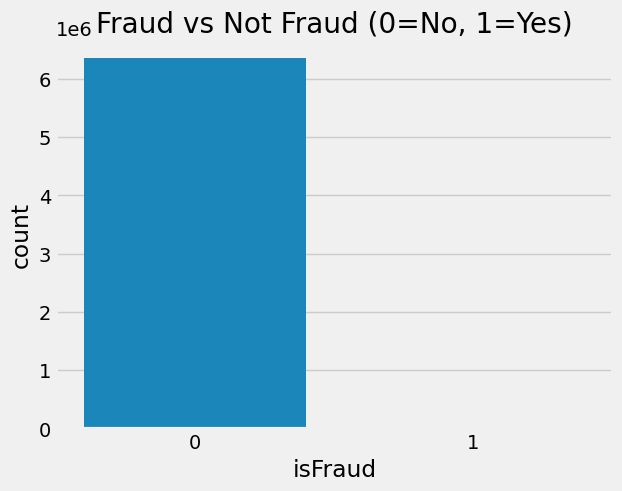

isFraud
0    6354407
1       8213
Name: count, dtype: int64


In [5]:
sns.countplot(x='isFraud', data=df)
plt.title("Fraud vs Not Fraud (0=No, 1=Yes)")
plt.show()
print(df['isFraud'].value_counts())

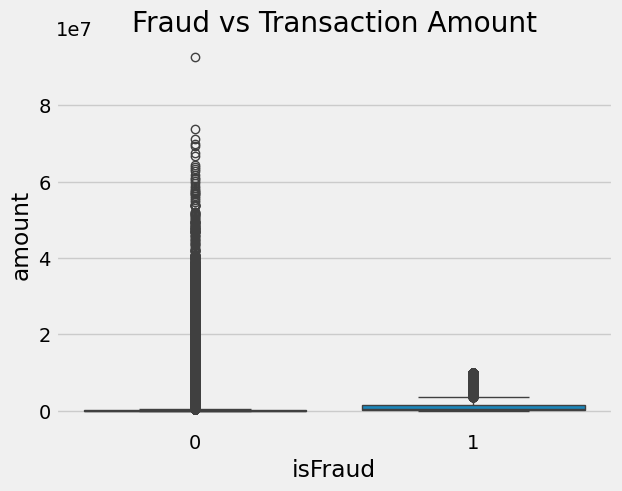

In [6]:
sns.boxplot(x='isFraud', y='amount', data=df)
plt.title("Fraud vs Transaction Amount")
plt.show()

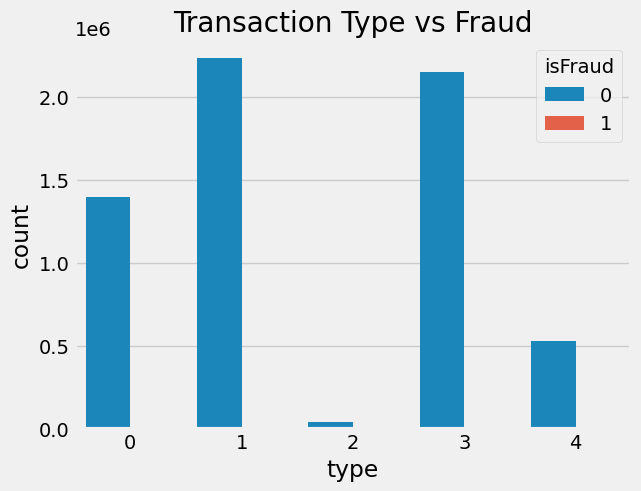

In [7]:
sns.countplot(x='type', hue='isFraud', data=df)
plt.title("Transaction Type vs Fraud")
plt.show()

In [8]:
df.describe()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.714150e+00,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,1.350117e+00,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.000000e+00,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,1.000000e+00,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,3.000000e+00,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,4.000000e+00,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [9]:
print("Shape:", df.shape)

Shape: (6362620, 9)


In [10]:
print("Null values in each column:")
print(df.isnull().sum())
# Good news: This dataset has NO null values!

Null values in each column:
step              0
type              0
amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 9 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            int64  
 2   amount          float64
 3   oldbalanceOrg   float64
 4   newbalanceOrig  float64
 5   oldbalanceDest  float64
 6   newbalanceDest  float64
 7   isFraud         int64  
 8   isFlaggedFraud  int64  
dtypes: float64(5), int64(4)
memory usage: 436.9 MB


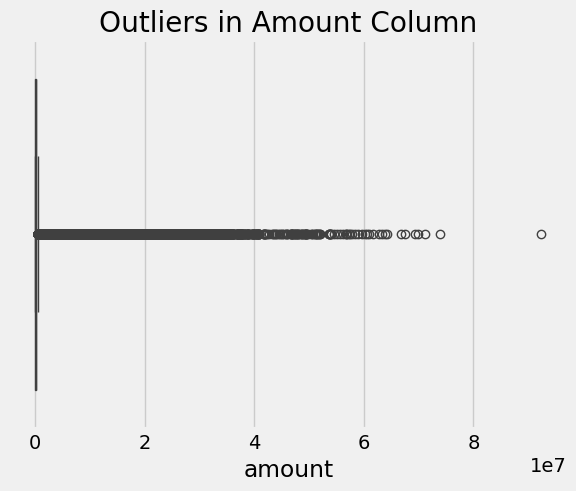

In [12]:
sns.boxplot(x=df['amount'])
plt.title("Outliers in Amount Column")
plt.show()

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])
print("Encoding done! Unique type values:", df['type'].unique())

Encoding done! Unique type values: [3 4 1 2 0]


In [14]:
X = df.drop('isFraud', axis=1)   # All columns except target
y = df['isFraud']                  # Only the target column

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (6362620, 8)
y shape: (6362620,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (5090096, 8)
Testing size: (1272524, 8)


In [16]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                              accuracy_score)
print("Model libraries ready!")

Model libraries ready!


In [17]:
from sklearn.utils import resample

X_train, y_train = resample(X_train, y_train, 
                             n_samples=50000,
                             random_state=42)

X_test, y_test = resample(X_test, y_test,
                           n_samples=10000,
                           random_state=42)

print("✅ New Training size:", X_train.shape)
print("✅ New Testing size:", X_test.shape)

✅ New Training size: (50000, 8)
✅ New Testing size: (10000, 8)


In [18]:
def RandomForest(X_train, X_test, y_train, y_test):
    model = RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        n_estimators=50
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    print("=== Random Forest ===")
    print("Accuracy:", acc)
    print(confusion_matrix(y_test, pred))
    print(classification_report(y_test, pred))
    return model, acc

rf_model, rf_acc = RandomForest(X_train, X_test, y_train, y_test)

=== Random Forest ===
Accuracy: 0.9997
[[9989    0]
 [   3    8]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9989
           1       1.00      0.73      0.84        11

    accuracy                           1.00     10000
   macro avg       1.00      0.86      0.92     10000
weighted avg       1.00      1.00      1.00     10000



In [19]:
def RandomForest(X_train, X_test, y_train, y_test):
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    print("=== Random Forest ===")
    print("Accuracy:", acc)
    print(confusion_matrix(y_test, pred))
    print(classification_report(y_test, pred))
    return model, acc

rf_model, rf_acc = RandomForest(X_train, X_test, y_train, y_test)

=== Random Forest ===
Accuracy: 0.9997
[[9989    0]
 [   3    8]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9989
           1       1.00      0.73      0.84        11

    accuracy                           1.00     10000
   macro avg       1.00      0.86      0.92     10000
weighted avg       1.00      1.00      1.00     10000



In [20]:
def Decisiontree(X_train, X_test, y_train, y_test):
    model = DecisionTreeClassifier(random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    print("=== Decision Tree ===")
    print("Accuracy:", acc)
    print(confusion_matrix(y_test, pred))
    print(classification_report(y_test, pred))
    return model, acc

dt_model, dt_acc = Decisiontree(X_train, X_test, y_train, y_test)

=== Decision Tree ===
Accuracy: 0.9995
[[9986    3]
 [   2    9]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9989
           1       0.75      0.82      0.78        11

    accuracy                           1.00     10000
   macro avg       0.87      0.91      0.89     10000
weighted avg       1.00      1.00      1.00     10000



In [21]:
def ExtraTree(X_train, X_test, y_train, y_test):
    model = ExtraTreesClassifier(random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    print("=== Extra Trees ===")
    print("Accuracy:", acc)
    print(confusion_matrix(y_test, pred))
    print(classification_report(y_test, pred))
    return model, acc

et_model, et_acc = ExtraTree(X_train, X_test, y_train, y_test)

=== Extra Trees ===
Accuracy: 0.9995
[[9989    0]
 [   5    6]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9989
           1       1.00      0.55      0.71        11

    accuracy                           1.00     10000
   macro avg       1.00      0.77      0.85     10000
weighted avg       1.00      1.00      1.00     10000



In [22]:
def SupportVector(X_train, X_test, y_train, y_test):
    model = SVC(random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    print("=== SVM ===")
    print("Accuracy:", acc)
    print(confusion_matrix(y_test, pred))
    print(classification_report(y_test, pred))
    return model, acc

svm_model, svm_acc = SupportVector(X_train, X_test, y_train, y_test)

=== SVM ===
Accuracy: 0.9992
[[9989    0]
 [   8    3]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9989
           1       1.00      0.27      0.43        11

    accuracy                           1.00     10000
   macro avg       1.00      0.64      0.71     10000
weighted avg       1.00      1.00      1.00     10000



In [23]:
def xgboost(X_train, X_test, y_train, y_test):
    model = XGBClassifier(random_state=42, eval_metric='logloss')
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    print("=== XGBoost ===")
    print("Accuracy:", acc)
    print(confusion_matrix(y_test, pred))
    print(classification_report(y_test, pred))
    return model, acc

xgb_model, xgb_acc = xgboost(X_train, X_test, y_train, y_test)

=== XGBoost ===
Accuracy: 0.9998
[[9989    0]
 [   2    9]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9989
           1       1.00      0.82      0.90        11

    accuracy                           1.00     10000
   macro avg       1.00      0.91      0.95     10000
weighted avg       1.00      1.00      1.00     10000



In [24]:
model_names = ['Random Forest', 'Decision Tree', 'Extra Trees', 'SVM', 'XGBoost']
accuracies  = [rf_acc, dt_acc, et_acc, svm_acc, xgb_acc]

for name, acc in zip(model_names, accuracies):
    print(f"{name}: {acc:.4f} ({acc*100:.2f}%)")

best_index = accuracies.index(max(accuracies))
print(f"\n✅ Best Model: {model_names[best_index]} with {max(accuracies)*100:.2f}% accuracy")

Random Forest: 0.9997 (99.97%)
Decision Tree: 0.9995 (99.95%)
Extra Trees: 0.9995 (99.95%)
SVM: 0.9992 (99.92%)
XGBoost: 0.9998 (99.98%)

✅ Best Model: XGBoost with 99.98% accuracy


In [25]:
import pickle

# Save whichever scored highest (guide says SVM is best ~79%)
best_model = svm_model   # change this if another model wins

with open('../model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("✅ Model saved as model.pkl")

✅ Model saved as model.pkl
